In [7]:
import numpy as np
import time
from gridcp import GridDetector
from gridcp.calibration import (
    calibrate_threshold,
    draw_samples,
    mc_alarm_times,
    with_calibrated_threshold,
)
from gridcp.scores import MeanCUSUM, MeanCUSUMUnknownVariance

## New API calibration + run (old sandbox equivalent)
This section mirrors the old API sandbox flow for univariate mean-change detection, but uses the new API and `gridcp.calibration` helpers.

In [8]:
stream_len = 100
n_paths_calibrate = 10_000
n_paths_eval = 1_000
n_features = 10
changepoint = stream_len // 2

### Known variance univariate mean change

In [9]:
def normal_sampler(rng, size, loc, scale):
    return rng.normal(size=size, loc=loc, scale=scale)


rng_cal = np.random.default_rng(42)
rng_data = np.random.default_rng(123)

#### MC calibration serial new API:

In [10]:
# Known variance: calibrate threshold under null ---- NONPARALLELL
known_score = MeanCUSUM(n_features=n_features)
critical_value_known_var = calibrate_threshold(
    known_score,
    alpha=0.05,
    stream_len=stream_len,
    n_paths=n_paths_calibrate,
    pre_sampler=normal_sampler,
    pre_kwargs={"size": n_features, "loc": 0.0, "scale": 1.0},
    rng=rng_cal,
    n_features=n_features,
    parallel=False,
)
known_detector = GridDetector(score=known_score, threshold=critical_value_known_var)
print("Known-variance critical value:", critical_value_known_var)

Known-variance critical value: 4.9448472288012475


#### MC calibration serial old API:

In [11]:
import gridcp.old_api as old_api

detector = old_api.make_univariate_mean_change_detector()
start = time.perf_counter()
detector.calibrate_false_alarm(
    alpha=0.05,
    N=stream_len,
    K=n_paths_calibrate,
    null_dist=np.random.normal,
)
stop = time.perf_counter()
print(detector._state["penalty_constant"])

2.95004427331863


#### MC calibration parallell new API:

In [12]:
# Known variance: calibrate threshold under null ---- Parallell
known_score = MeanCUSUM(n_features=n_features)
critical_value_known_var = calibrate_threshold(
    known_score,
    alpha=0.05,
    stream_len=stream_len,
    n_paths=n_paths_calibrate,
    pre_sampler=normal_sampler,
    pre_kwargs={"size": n_features, "loc": 0.0, "scale": 1.0},
    rng=rng_cal,
    n_features=n_features,
    parallel=True,
    n_jobs=8,
    strict_equivalence=False,
)
known_detector = GridDetector(score=known_score, threshold=critical_value_known_var)
print("Known-variance critical value:", critical_value_known_var)

Known-variance critical value: 4.924019917451288


#### Use mc_alarm_times to check if correctly calibrated:

In [13]:
# Simulate streams and record first alarm time in each path.
detect_times = mc_alarm_times(
    detector=known_detector,
    n_paths=n_paths_eval,
    stream_len=stream_len,
    n_features=n_features,
    pre_sampler=normal_sampler,
    pre_kwargs={"size": n_features, "loc": 0.0, "scale": 1.0},
    rng=1234,
    parallel=True,
)

print("Known-variance false alarm prob:", np.mean(detect_times <= stream_len))

Known-variance false alarm prob: 0.044


In [14]:
detect_times

array([  4, 101, 101, 101, 101,   2, 101, 101, 101, 101, 101, 101, 101,
       101, 101, 101, 101, 101, 101, 101, 101,   2, 101, 101, 101, 101,
       101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,   2,   2,
       101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,
       101,   2, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,
       101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,
       101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,
       101, 101,   2, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,
       101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,
       101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,   5, 101,
       101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,
       101, 101, 101, 101, 101,   4,   2, 101, 101, 101, 101, 101, 101,
       101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,
       101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 10

#### Make plot of detection delay:

In [8]:
post_change_mus = np.linspace(0.0, 5.0, num=20)

dds = []
i = 0
for post_change_mu in post_change_mus:
    print(i)
    i = i + 1
    detect_times = mc_alarm_times(
        detector=known_detector,
        n_paths=n_paths_eval,
        stream_len=stream_len,
        n_features=n_features,
        pre_sampler=normal_sampler,
        pre_kwargs={"size": n_features, "loc": 0.0, "scale": 1.0},
        post_sampler=normal_sampler,
        post_kwargs={"size": n_features, "loc": post_change_mu, "scale": 1.0},
        changepoint=changepoint,
        rng=1234,
        parallel=True,
    )
    # ignore paths with preemptive false alarms; compute detection delay only on paths that alarm after the change
    dd = detect_times - changepoint
    dd = dd[dd > 0]
    dd = np.mean(dd) if len(dd) > 0 else np.nan
    dds.append(dd)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


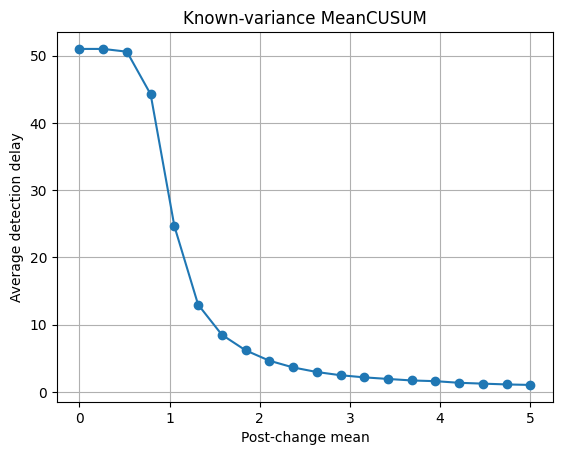

In [9]:
# plot detection delay vs post-change mean
import matplotlib.pyplot as plt

plt.plot(post_change_mus, dds, marker="o")
plt.xlabel("Post-change mean")
plt.ylabel("Average detection delay")
plt.title("Known-variance MeanCUSUM")
plt.grid()